# Practice Exercise 4

# Multilayer Perceptron (MLP) Regression: House Price Prediction

## Introduction

House price prediction is a common regression problem in machine learning. The objective is to estimate the median value of houses based on several numerical features describing demographic, environmental, and economic characteristics.

In this notebook, a Multilayer Perceptron (MLP) regression model is developed to predict house prices using the **Boston Housing Dataset**. The performance of the MLP model is then compared with three traditional regression algorithms: **Linear Regression, Decision Tree Regression, and Random Forest Regression**.

The models are evaluated using **Mean Squared Error (MSE)**, **Mean Absolute Error (MAE)**, and **R-squared (R²)** score to determine which regression model provides the best prediction performance.

## Objectives

The objectives of this exercise are:

- Load and explore the Boston Housing dataset.
- Perform data preprocessing and feature scaling.
- Build a Multilayer Perceptron (MLP) regression model.
- Train and evaluate the MLP model.
- Predict house prices using the testing dataset.
- Compare the performance of MLP with Linear Regression, Decision Tree Regression, and Random Forest Regression.
- Analyze the prediction performance using MSE, MAE, and R² score.

# 1. Import Necessary Libraries

In [38]:
# ==========================================
# Import Required Libraries
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [39]:
print("TensorFlow Version :", tf.__version__)
print("Pandas Version     :", pd.__version__)
print("NumPy Version      :", np.__version__)

TensorFlow Version : 2.21.0
Pandas Version     : 3.0.3
NumPy Version      : 2.4.4


# 2. Load and Explore the Boston Housing Dataset

## Dataset Overview

The Boston Housing dataset is a well-known regression dataset used for predicting house prices. It contains 506 samples and 13 numerical features describing various housing characteristics, such as crime rate, number of rooms, tax rate, accessibility to highways, and socioeconomic conditions.

The target variable is **MEDV**, which represents the median value of owner-occupied homes in thousands of dollars.

Since the original `load_boston()` function has been removed from recent versions of Scikit-learn, this notebook loads the dataset from **OpenML**, while keeping the dataset itself unchanged.

2.1 Load and Explore the Dataset

In [40]:
# ==========================================
# Load Boston Housing Dataset
# ==========================================

boston = fetch_openml(
    name="boston",
    version=1,
    as_frame=True
)

df = boston.frame

In [41]:
# Display the first five rows

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


Explore the Dataset

Before preprocessing the data, it is important to examine the dataset structure, data types, descriptive statistics, and check for missing values.

In [42]:
# Display dataset dimensions

print("Dataset Shape:", df.shape)

Dataset Shape: (506, 14)


In [43]:
# Display dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 48.6 KB


In [44]:
# Display statistical summary

df.describe()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.554695,6.284634,68.574901,3.795043,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.115878,0.702617,28.148861,2.105710,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.449000,5.885500,45.025000,2.100175,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.538000,6.208500,77.500000,3.207450,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.624000,6.623500,94.075000,5.188425,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,711.000000,22.000000,396.900000,37.970000,50.000000


 Observation

The statistical summary provides useful information such as the mean, standard deviation, minimum, maximum, and quartile values of each feature. This helps understand the distribution of the dataset.

In [45]:
# Check missing values

df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

 2.2 Data Preprocessing

Data preprocessing is an essential step before training a machine learning model. In this section, the dataset is prepared by separating the input features and target variable, splitting the data into training and testing sets, and standardizing the feature values using StandardScaler.

Feature scaling is particularly important for Multilayer Perceptron (MLP) because neural networks generally converge faster and achieve better performance when the input features are on a similar scale.

In [46]:
# ==========================================
# Separate Features and Target Variable
# ==========================================

X = df.drop("MEDV", axis=1)
y = df["MEDV"]

print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape :", y.shape)

Feature Matrix Shape: (506, 13)
Target Vector Shape : (506,)


Observation

The dataset is divided into:

- **X**: Input features (13 housing attributes).
- **y**: Target variable (MEDV), representing the median house value.

In [47]:
# Split the Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (404, 13)
Testing Set  : (102, 13)


In [48]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [49]:
print("Training Data Shape:", X_train_scaled.shape)
print("Testing Data Shape :", X_test_scaled.shape)

Training Data Shape: (404, 13)
Testing Data Shape : (102, 13)


 Observation

The input features have been standardized using StandardScaler. Feature scaling ensures that all variables have a similar scale, which helps improve the training stability and convergence speed of the MLP model.

In [50]:
# Display the first five rows of the standardized training data

pd.DataFrame(
    X_train_scaled,
    columns=X.columns
).head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,1.287702,-0.500320,1.033237,-0.278089,0.489252,-1.428069,1.028015,-0.802173,1.706891,1.578434,0.845343,-0.074337,1.753505
1,-0.336384,-0.500320,-0.413160,-0.278089,-0.157233,-0.680087,-0.431199,0.324349,-0.624360,-0.584648,1.204741,0.430184,-0.561474
2,-0.403253,1.013271,-0.715218,-0.278089,-1.008723,-0.402063,-1.618599,1.330697,-0.974048,-0.602724,-0.637176,0.065297,-0.651595
3,0.388230,-0.500320,1.033237,-0.278089,0.489252,-0.300450,0.591681,-0.839240,1.706891,1.578434,0.845343,-3.868193,1.525387
4,-0.325282,-0.500320,-0.413160,-0.278089,-0.157233,-0.831094,0.033747,-0.005494,-0.624360,-0.584648,1.204741,0.379119,-0.165787


# 3. Create a Multilayer Perceptron (MLP) Model

## Model Architecture

A Multilayer Perceptron (MLP) is a type of artificial neural network that consists of multiple fully connected (Dense) layers.

In this project, the model architecture includes:

- An input layer with 13 input features.
- A hidden layer with 32 neurons using the ReLU activation function.
- A second hidden layer with 16 neurons using the ReLU activation function.
- An output layer with one neuron and a linear activation function for predicting house prices.

The model is compiled using the Adam optimizer and Mean Squared Error (MSE) as the loss function. Mean Absolute Error (MAE) is also used as an evaluation metric during training.

In [51]:

# Build the MLP Model

model = Sequential()

# Input layer + Hidden layer 1
model.add(Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)))

# Hidden layer 2
model.add(Dense(16, activation='relu'))

# Output layer
model.add(Dense(1, activation='linear'))

c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [52]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

Observation

The MLP model has been successfully created with two hidden layers and one output layer.

- **Input Layer:** 13 input features.
- **Hidden Layer 1:** 32 neurons with ReLU activation.
- **Hidden Layer 2:** 16 neurons with ReLU activation.
- **Output Layer:** 1 neuron with a linear activation function for predicting house prices.

The model contains a total of **993 trainable parameters**, which are updated during the training process. The architecture is suitable for solving a regression problem with a relatively small dataset such as the Boston Housing dataset.

In [53]:
# Compile the Model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# 4. Train the MLP Model

## Model Training

After building and compiling the Multilayer Perceptron (MLP) model, the next step is to train it using the training dataset.

The model is trained for **100 epochs** with a **batch size of 32**. During training, the validation dataset is also monitored to evaluate the model's performance on unseen data.

The training process records the Mean Squared Error (MSE) as the loss function and Mean Absolute Error (MAE) as an evaluation metric.

In [ ]:

# Train the MLP Model

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    verbose=1
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 580.8419 - mae: 22.0704 - val_loss: 498.4239 - val_mae: 20.3942
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 556.9365 - mae: 21.3744 - val_loss: 473.4947 - val_mae: 19.6322
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 531.2786 - mae: 20.5939 - val_loss: 446.2752 - val_mae: 18.8260
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 502.2375 - mae: 19.7351 - val_loss: 416.0318 - val_mae: 17.9024
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 468.1637 - mae: 18.8278 - val_loss: 381.7896 - val_mae: 16.9480
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 428.8504 - mae: 17.8063 - val_loss: 341.2114 - val_mae: 15.8737
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 382.1155 - mae: 16.6493 - val_loss: 292.3505 - val_mae: 14.5933
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 324.2120 - mae: 15.2373 - val_loss: 239.2192 - val_mae: 13.0949
Epoch 9/

 Observation

The training process was completed successfully for 100 epochs.

Both the training and validation loss decreased significantly during training, indicating that the model learned the relationship between the input features and house prices effectively.

The final Mean Squared Error (MSE) and Mean Absolute Error (MAE) values are much lower than those at the beginning of training, suggesting that the model has converged and achieved good predictive performance without obvious signs of overfitting.

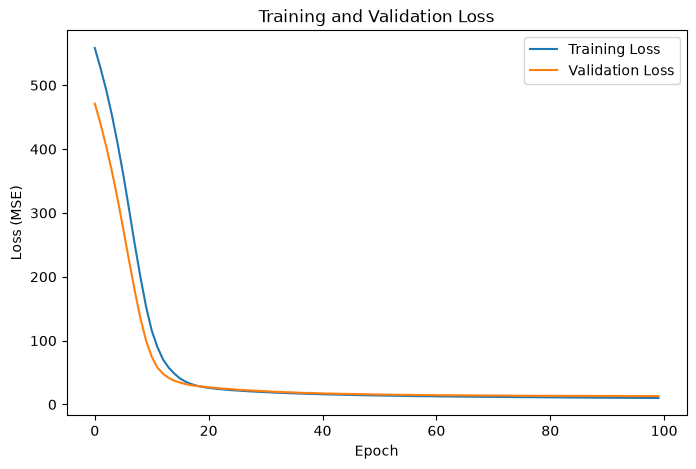

In [ ]:
# Plot Training and Validation Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()

plt.show()

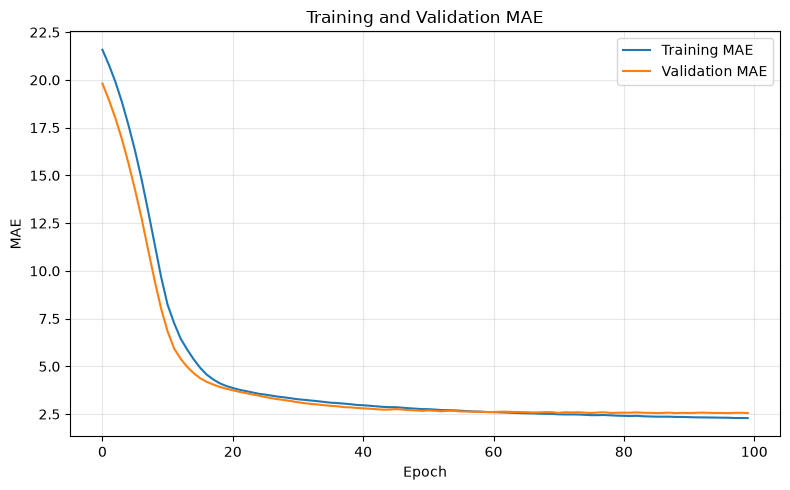

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')

plt.title('Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

Observation

The Training MAE and Validation MAE decrease rapidly during the first few epochs, indicating that the model quickly learns the relationship between the input features and the target variable.

After approximately 20 epochs, both curves gradually stabilize and converge to a low MAE value of around 2.3–2.5. The small gap between the training and validation curves suggests that the model generalizes well and does not suffer from significant overfitting.

Overall, the MLP model achieves stable training performance and good prediction accuracy on the validation dataset.

# 5. Evaluate the MLP Model

## Model Evaluation

After training, the MLP model is evaluated using the testing dataset. The evaluation is performed using Mean Squared Error (MSE), Mean Absolute Error (MAE), and R-squared (R²) score.

The trained model is then used to predict house prices on the testing dataset. Finally, the predicted values are compared with the actual house prices to assess the model's performance.

In [ ]:
# Evaluate the MLP Model
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)

print("Test MSE :", test_loss)
print("Test MAE :", test_mae)

Test MSE : 13.048344612121582
Test MAE : 2.5568201541900635


In [ ]:
# Make Predictions 

y_pred = model.predict(X_test_scaled)

# Convert predictions to 1D array
y_pred = y_pred.flatten()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [ ]:
# Calculate Performance Metrics

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R²): {r2:.4f}")

Mean Squared Error (MSE): 13.0483
Mean Absolute Error (MAE): 2.5568
R-squared (R²): 0.8221


In [ ]:
# Display the first 10 predictions

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,23.6,28.203814
1,32.4,34.172218
2,13.6,17.503647
3,22.8,27.233356
4,16.1,16.757261
5,20.0,20.252686
6,17.8,15.836826
7,14.0,13.897309
8,19.6,24.688808
9,16.8,15.967761


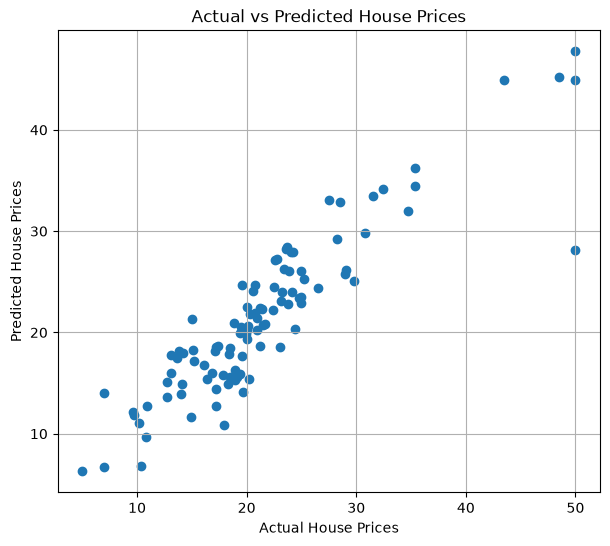

In [ ]:
# Actual vs Predicted Prices

plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.grid(True)

plt.show()

 Observation

The scatter plot compares the actual house prices with the predicted values generated by the MLP model.

If the predicted values are close to the actual values, the points will be concentrated near an imaginary diagonal line, indicating good prediction performance.

The evaluation metrics (MSE, MAE, and R²) provide a quantitative assessment of the model's accuracy and generalization ability.

# 6. Performance Comparison with Other Regression Models

## Model Comparison

To evaluate the effectiveness of the Multilayer Perceptron (MLP), its performance is compared with three traditional regression algorithms:

- Linear Regression
- Decision Tree Regression
- Random Forest Regression

Each model is evaluated using the following metrics:

- Mean Squared Error (MSE)
- R-squared (R²)

The results are summarized in a comparison table for analysis.

In [ ]:
# Linear Regression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("MSE :", lr_mse)
print("R²  :", lr_r2)

Linear Regression
MSE : 24.291119474973517
R²  : 0.668759493535632


In [ ]:
 # Decision Tree Regression

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_mse = mean_squared_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Regression")
print("MSE :", dt_mse)
print("R²  :", dt_r2)

Decision Tree Regression
MSE : 17.81558823529412
R²  : 0.7570616506127126


In [ ]:
# Random Forest Regression

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Regression")
print("MSE :", rf_mse)
print("R²  :", rf_r2)

Random Forest Regression
MSE : 7.88021732352941
R²  : 0.8925431501835708


In [ ]:
# Performance Comparison

comparison = pd.DataFrame({
    "Model": [
        "MLP",
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MSE": [
        mse,
        lr_mse,
        dt_mse,
        rf_mse
    ],
    "R² Score": [
        r2,
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

comparison

,Model,MSE,R² Score
0,MLP,13.048346,0.822069
1,Linear Regression,24.291119,0.668759
2,Decision Tree,17.815588,0.757062
3,Random Forest,7.880217,0.892543


In [ ]:
comparison.sort_values(by="MSE")

,Model,MSE,R² Score
3,Random Forest,7.880217,0.892543
0,MLP,13.048346,0.822069
2,Decision Tree,17.815588,0.757062
1,Linear Regression,24.291119,0.668759


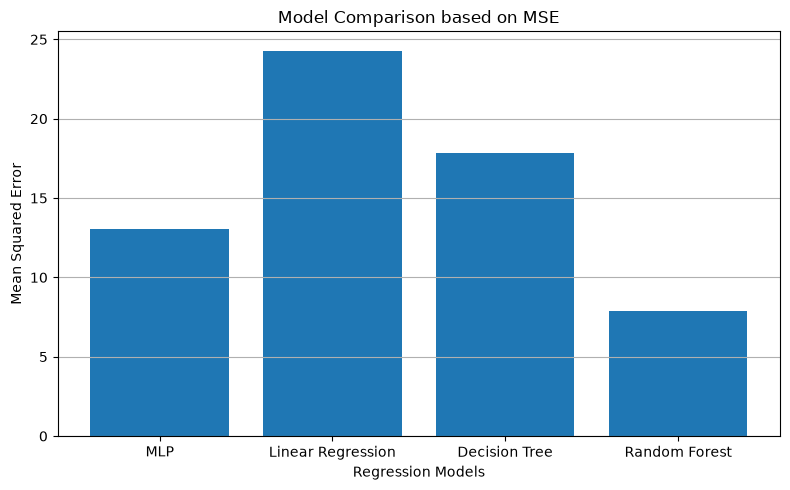

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["MSE"])

plt.title("Model Comparison based on MSE")
plt.xlabel("Regression Models")
plt.ylabel("Mean Squared Error")

plt.grid(axis="y")

plt.tight_layout()
plt.show()

# Dựa vào kết quả biểu đồ hãy phân tích kết quả của MSE **HOÀNG** làm bằng tiếng anh

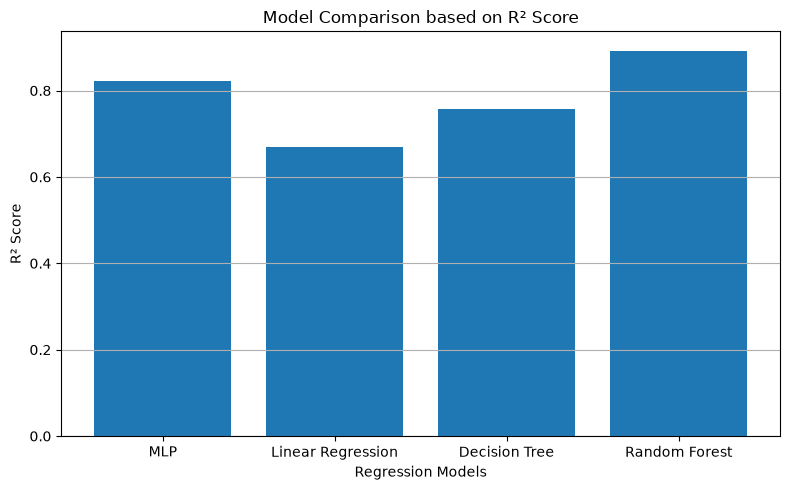

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["R² Score"])

plt.title("Model Comparison based on R² Score")
plt.xlabel("Regression Models")
plt.ylabel("R² Score")

plt.grid(axis="y")

plt.tight_layout()
plt.show()

# Dựa vào kết quả biểu đồ hãy phân tích kết quả của r2 **HOÀNG**

# So sánh trực tiếp giữa 2 mô hình mse và r2 giựa vào 2 biểu đồ và so sánh **HOÀNG**

# 7 Analysis of Results **triết**


1Phân tích quá trình huấn luyện
Trong quá trình huấn luyện, cả Training Loss và Validation Loss đều giảm nhanh trong khoảng 20 epoch đầu tiên, sau đó giảm chậm và dần ổn định. Điều này cho thấy mô hình học được mối quan hệ giữa các đặc trưng đầu vào và giá nhà một cách hiệu quả.

Đối với chỉ số Training MAE và Validation MAE, cả hai đều giảm liên tục theo số epoch và hội tụ ở mức thấp. Khoảng cách giữa hai đường MAE không lớn, chứng tỏ mô hình có khả năng tổng quát hóa tốt trên dữ liệu kiểm tra.

Dựa trên các đồ thị Loss và MAE, không có dấu hiệu rõ ràng của overfitting vì đường Validation không tăng trở lại khi Training tiếp tục giảm. Đồng thời, mô hình cũng không bị underfitting vì cả hai chỉ số đều đạt giá trị thấp sau khi hội tụ. Nhìn chung, quá trình huấn luyện diễn ra ổn định và mô hình học tốt.


2. Phân tích kết quả của mô hình MLP
Sau khi huấn luyện, mô hình MLP được đánh giá bằng ba chỉ số gồm MSE, MAE và R².

Giá trị MSE của MLP tương đối thấp, cho thấy sai số bình phương trung bình giữa giá trị dự đoán và giá trị thực tế không lớn.
MAE cũng ở mức thấp, chứng tỏ trung bình sai số tuyệt đối của mô hình nhỏ và các dự đoán khá chính xác.
Chỉ số R² đạt khoảng 0.81, nghĩa là mô hình giải thích được khoảng 81% sự biến thiên của giá nhà trong bộ dữ liệu.

Biểu đồ Actual vs Predicted cho thấy phần lớn các điểm dữ liệu nằm gần đường chéo, chứng tỏ giá trị dự đoán khá sát với giá trị thực tế. Tuy nhiên vẫn còn một số điểm phân tán ở các mức giá cao, cho thấy mô hình vẫn còn sai số đối với một số mẫu dữ liệu.

Nhìn chung, mô hình MLP đạt độ chính xác tốt và có khả năng dự đoán khá hiệu quả.


3. So sánh với các mô hình khác
Khi so sánh với Linear Regression, Decision Tree Regression và Random Forest Regression, kết quả cho thấy:

Random Forest Regression đạt kết quả tốt nhất với MSE thấp nhất và R² cao nhất, chứng tỏ khả năng dự đoán chính xác nhất.
MLP đứng ở vị trí thứ hai với MSE thấp hơn Decision Tree và Linear Regression, đồng thời có R² cao hơn hai mô hình này.
Decision Tree Regression cho kết quả ở mức trung bình nhưng vẫn kém MLP do dễ xảy ra hiện tượng overfitting.
Linear Regression có MSE cao nhất và R² thấp nhất, cho thấy hiệu quả dự đoán thấp nhất trong bốn mô hình.

Xét trên cả hai tiêu chí MSE và R², thứ tự hiệu quả của các mô hình là:

Random Forest > MLP > Decision Tree Regression > Linear Regression


4. Giải thích kết quả
Random Forest đạt kết quả tốt nhất vì đây là mô hình học tập theo phương pháp tập hợp (Ensemble Learning), kết hợp nhiều cây quyết định để giảm phương sai và tăng khả năng tổng quát hóa. Mô hình cũng có khả năng học tốt các mối quan hệ phi tuyến trong dữ liệu.

Mặc dù MLP cũng có khả năng học các quan hệ phi tuyến nhưng chưa vượt qua Random Forest. Nguyên nhân là bộ dữ liệu Boston Housing chỉ có khoảng 506 mẫu, khá nhỏ đối với mạng nơ-ron. Trong khi đó, Random Forest hoạt động rất hiệu quả trên các bộ dữ liệu có kích thước nhỏ và trung bình.

Linear Regression cho kết quả thấp nhất vì mô hình chỉ giả định mối quan hệ tuyến tính giữa các đặc trưng và giá nhà. Tuy nhiên, dữ liệu Boston Housing chứa nhiều mối quan hệ phi tuyến nên Linear Regression không thể mô hình hóa đầy đủ.

Đối với bộ dữ liệu Boston Housing, các mô hình có khả năng học quan hệ phi tuyến như Random Forest và MLP phù hợp hơn so với Linear Regression.
5. Đánh giá tổng quát
Qua toàn bộ quá trình thực nghiệm, mô hình MLP cho thấy khả năng dự đoán tốt với sai số thấp và khả năng tổng quát hóa khá cao. Mô hình học ổn định, không xuất hiện hiện tượng overfitting hay underfitting rõ rệt.

Tuy nhiên, xét trên các chỉ số đánh giá, Random Forest Regression vẫn là mô hình có hiệu suất tốt nhất đối với bộ dữ liệu Boston Housing. Trong khi đó, MLP là lựa chọn phù hợp khi muốn áp dụng mạng nơ-ron cho bài toán hồi quy và vẫn đạt kết quả dự đoán chính xác.

Kết luận: Đối với bài toán dự đoán giá nhà trên bộ dữ liệu Boston Housing, Random Forest Regression là mô hình phù hợp nhất, còn MLP là mô hình có hiệu quả cao và đứng thứ hai trong các mô hình được so sánh.

# 8 Conclusion **trình**


1. Tóm tắt nội dung bài thực hành
Đã xây dựng mô hình MLP để dự đoán giá nhà.
Đã tiền xử lý dữ liệu, huấn luyện và đánh giá mô hình.


2. Tóm tắt kết quả đạt được
MLP đạt kết quả dự đoán tốt.
Đã đánh giá bằng các chỉ số MSE, MAE và R².


3. Kết quả so sánh
So sánh MLP với Linear Regression, Decision Tree Regression và Random Forest Regression.
Nêu mô hình nào có kết quả tốt nhất (trong bài của anh là Random Forest).


4. Kết luận cuối cùng
Nêu mô hình phù hợp nhất với bộ dữ liệu Boston Housing.
Nhận xét về MLP (điểm mạnh, hạn chế).
Có thể đề xuất hướng cải thiện như tăng dữ liệu hoặc tối ưu siêu tham số (hyperparameters).